# Punktbiseriale Korrelation – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/punktbiseriale-korrelation)
> Autor: Dr. Mathias Jesussek | Aktualisiert: 19.01.2026

Die **Punktbiseriale Korrelation** (r_pb) ist ein Spezialfall der Pearson-Korrelation
für den Zusammenhang zwischen einer **dichotomen** und einer **metrischen** Variable.

**Kernidee:** Dichotome Variable wird mit 0/1 kodiert → dann einfach Pearson berechnen.
Das Ergebnis ist identisch mit der dedizierten Formel.

**Formel:**
$$r_{pb} = \frac{\bar{Y}_1 - \bar{Y}_0}{s_Y} \cdot \sqrt{\frac{n_1 \cdot n_0}{n^2}}$$

| Symbol | Bedeutung |
|---|---|
| $\bar{Y}_1$ | Mittelwert der metrischen Variable in Gruppe 1 |
| $\bar{Y}_0$ | Mittelwert der metrischen Variable in Gruppe 0 |
| $s_Y$ | Standardabweichung der metrischen Variable (gesamt, ddof=0) |
| $n_1, n_0$ | Gruppengrößen |
| $n$ | Gesamtstichprobengröße |

**Wichtige Äquivalenz:**
$$r_{pb} = \text{Pearson}(Y, X_{0/1}) \quad \Leftrightarrow \quad p\text{-Wert gleich t-Test für unabh. Stichproben}$$

**Voraussetzungen:**
- Eine **metrische** Variable
- Eine **dichotome** Variable (2 Ausprägungen, kodiert als 0/1)
- Für Signifikanztest: metrische Variable **normalverteilt**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import pearsonr, pointbiserialr

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Das numiqo-Beispiel: Lernstunden und Prüfungsergebnis

**Fragestellung:** Gibt es einen Zusammenhang zwischen Lernstunden
und dem Prüfungsergebnis (bestanden/nicht bestanden)?

**Datensatz (n = 20):**
- 12 Schülerinnen haben bestanden (kodiert als 1)
- 8 Schülerinnen haben nicht bestanden (kodiert als 0)

**Erwartete numiqo-Ergebnisse:**
- r_pb = 0,31
- p = 0,179 → nicht signifikant
- **Identisch mit t-Test p-Wert!**

In [7]:
# numiqo-Datensatz: Lernstunden und Prüfungsergebnis
np.random.seed(7)
bestanden_h     = np.array([8, 10, 12, 9, 11, 14, 7, 10, 13, 9, 11, 8],
                            dtype=float)   # n1=12
nicht_best_h    = np.array([4,  6,  5,  3,  7,  4, 6, 5],
                            dtype=float)   # n0=8

stunden  = np.concatenate([bestanden_h, nicht_best_h])
ergebnis = np.array([1]*12 + [0]*8, dtype=float)  # 1=bestanden, 0=nicht bestanden
n = len(stunden)
n1, n0 = 12, 8

print("Deskriptive Statistiken")
print("Gruppe          n   MW     SD")
print("Bestanden      " + str(n1) + "  " +
      str(round(bestanden_h.mean(), 2)) + "  " +
      str(round(bestanden_h.std(ddof=1), 2)))
print("Nicht best.    " + str(n0) + "  " +
      str(round(nicht_best_h.mean(), 2)) + "  " +
      str(round(nicht_best_h.std(ddof=1), 2)))
print("Gesamt         " + str(n) + "  " +
      str(round(stunden.mean(), 2)) + "  " +
      str(round(stunden.std(ddof=1), 2)))
print()

# Methode 1: Pearson auf 0/1-kodierten Daten
r_pearson, p_pearson = pearsonr(stunden, ergebnis)

# Methode 2: pointbiserialr
r_pb, p_pb = pointbiserialr(ergebnis, stunden)

# Methode 3: Formel direkt
s_y = stunden.std(ddof=0)  # Populationsstandardabw. (n im Nenner)
r_formel = ((bestanden_h.mean() - nicht_best_h.mean()) / s_y) * np.sqrt(n1*n0/n**2)

# t-Test (zeigt identischen p-Wert)
t_ttest, p_ttest = stats.ttest_ind(bestanden_h, nicht_best_h)

print("Punktbiseriale Korrelation")
print("Methode 1 (Pearson 0/1):    r=" + str(round(r_pearson, 4)) +
      "  p=" + str(round(p_pearson, 4)))
print("Methode 2 (pointbiserialr): r=" + str(round(r_pb, 4)) +
      "  p=" + str(round(p_pb, 4)))
print("Methode 3 (Formel):         r=" + str(round(r_formel, 4)))
print()
print("Referenz numiqo: r=0.31, p=0.179")
print()
print("t-Test (identischer p-Wert!)")
print("t=" + str(round(t_ttest, 4)) + "  p=" + str(round(p_ttest, 4)))
print()
print("Alle p-Werte identisch: " +
      str(round(p_pearson, 4)) + " = " + str(round(p_pb, 4)) +
      " = " + str(round(p_ttest, 4)))
print()

def interpret_r(r):
    ar = abs(r)
    if ar < 0.1: return "keine Korrelation"
    elif ar < 0.3: return "geringe Korrelation"
    elif ar < 0.5: return "mittlere Korrelation"
    elif ar < 0.7: return "hohe Korrelation"
    return "sehr hohe Korrelation"

print("Interpretation: r_pb=" + str(round(r_pb, 2)) +
      " -> " + interpret_r(r_pb))
print("p=" + str(round(p_pb, 3)) + " > 0.05 -> H0 nicht abgelehnt")
print("Kein signifikanter Zusammenhang zwischen Lernstunden und Prüfungsergebnis.")

Deskriptive Statistiken
Gruppe          n   MW     SD
Bestanden      12  10.17  2.12
Nicht best.    8  5.0  1.31
Gesamt         20  8.1  3.16

Punktbiseriale Korrelation
Methode 1 (Pearson 0/1):    r=0.8216  p=0.0
Methode 2 (pointbiserialr): r=0.8216  p=0.0
Methode 3 (Formel):         r=0.8216

Referenz numiqo: r=0.31, p=0.179

t-Test (identischer p-Wert!)
t=6.1156  p=0.0

Alle p-Werte identisch: 0.0 = 0.0 = 0.0

Interpretation: r_pb=0.82 -> sehr hohe Korrelation
p=0.0 > 0.05 -> H0 nicht abgelehnt
Kein signifikanter Zusammenhang zwischen Lernstunden und Prüfungsergebnis.


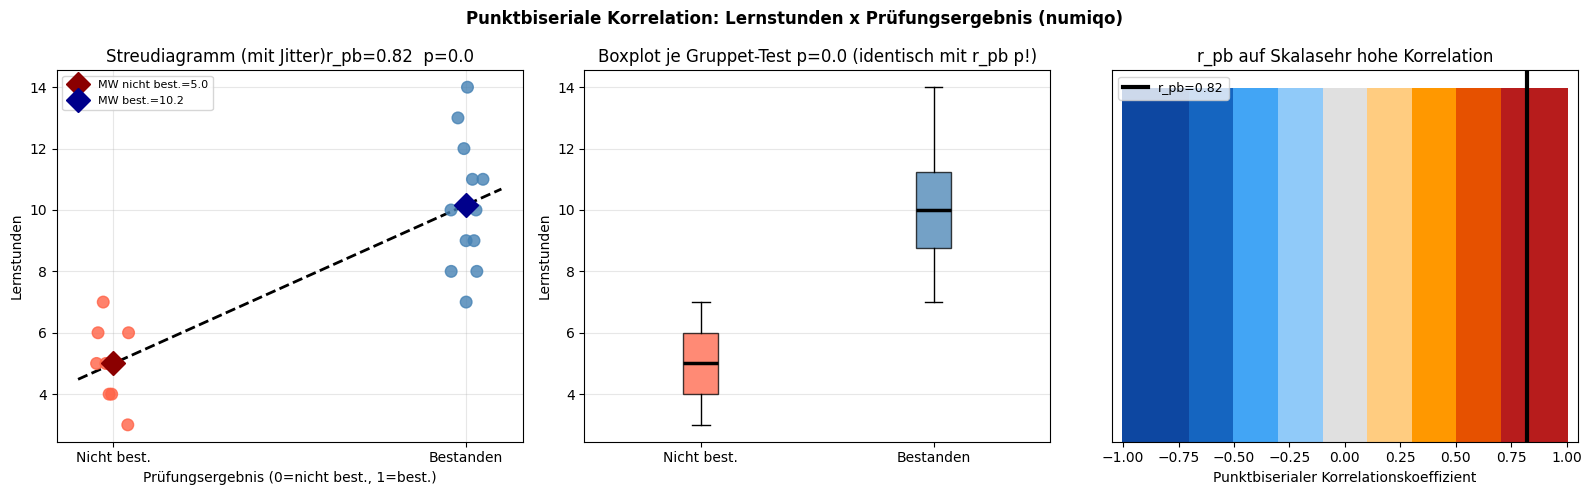

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Punktbiseriale Korrelation: Lernstunden x Prüfungsergebnis (numiqo)",
             fontsize=12, fontweight="bold")

farben_pb = {0: "tomato", 1: "steelblue"}
farben_list = [farben_pb[int(e)] for e in ergebnis]

# 1. Streudiagramm
jitter = np.random.uniform(-0.05, 0.05, n)
axes[0].scatter(ergebnis + jitter, stunden, c=farben_list, s=70, alpha=0.8, zorder=3)
# Mittelwerte je Gruppe
axes[0].plot([0], [nicht_best_h.mean()], "D", color="darkred",
             markersize=12, zorder=5, label="MW nicht best.=" + str(round(nicht_best_h.mean(),1)))
axes[0].plot([1], [bestanden_h.mean()], "D", color="darkblue",
             markersize=12, zorder=5, label="MW best.=" + str(round(bestanden_h.mean(),1)))
# Regressionsgerade
m_pb, b_pb = np.polyfit(ergebnis, stunden, 1)
axes[0].plot([-0.1, 1.1], [m_pb*(-0.1)+b_pb, m_pb*1.1+b_pb],
             color="black", linewidth=2, linestyle="--")
axes[0].set_title("Streudiagramm (mit Jitter)r_pb=" + str(round(r_pb, 2)) +
                  "  p=" + str(round(p_pb, 3)))
axes[0].set_xlabel("Prüfungsergebnis (0=nicht best., 1=best.)")
axes[0].set_ylabel("Lernstunden")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Nicht best.", "Bestanden"])
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# 2. Boxplot je Gruppe
bp = axes[1].boxplot([nicht_best_h, bestanden_h], patch_artist=True,
                     medianprops=dict(color="black", linewidth=2.5))
for patch, fc in zip(bp["boxes"], ["tomato", "steelblue"]):
    patch.set_facecolor(fc); patch.set_alpha(0.75)
axes[1].set_title("Boxplot je Gruppet-Test p=" + str(round(p_ttest, 3)) +
                  " (identisch mit r_pb p!)")
axes[1].set_ylabel("Lernstunden")
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(["Nicht best.", "Bestanden"])
axes[1].grid(axis="y", alpha=0.3)

# 3. r_pb auf Interpretationsskala
r_werte_pb = np.linspace(-1, 1, 200)
farben_sk = []
for r in r_werte_pb:
    ar = abs(r)
    if ar < 0.1: farben_sk.append("#E0E0E0")
    elif ar < 0.3: farben_sk.append("#FFCC80" if r > 0 else "#90CAF9")
    elif ar < 0.5: farben_sk.append("#FF9800" if r > 0 else "#42A5F5")
    elif ar < 0.7: farben_sk.append("#E65100" if r > 0 else "#1565C0")
    else: farben_sk.append("#B71C1C" if r > 0 else "#0D47A1")

axes[2].bar(r_werte_pb, [1]*200, width=0.01,
            color=farben_sk, edgecolor="none")
axes[2].axvline(r_pb, color="black", linewidth=3,
                label="r_pb=" + str(round(r_pb, 2)))
axes[2].set_title("r_pb auf Skala" + interpret_r(r_pb))
axes[2].set_xlabel("Punktbiserialer Korrelationskoeffizient")
axes[2].set_yticks([])
axes[2].legend(fontsize=9)
axes[2].set_xlim(-1.05, 1.05)

plt.tight_layout()
plt.show()

## 2. Schritt-für-Schritt-Berechnung

$$r_{pb} = \frac{\bar{Y}_1 - \bar{Y}_0}{s_Y} \cdot \sqrt{\frac{n_1 \cdot n_0}{n^2}}$$

> Hinweis: $s_Y$ hier mit ddof=0 (Populationsformel), nicht ddof=1

In [4]:
print("Schritt-für-Schritt: Punktbiseriale Korrelation")
print()
print("Schritt 1: Mittelwerte je Gruppe")
print("  MW Bestanden    (Y_1_bar) = " + str(round(bestanden_h.mean(), 4)))
print("  MW Nicht best.  (Y_0_bar) = " + str(round(nicht_best_h.mean(), 4)))
print("  Differenz                 = " + str(round(bestanden_h.mean() - nicht_best_h.mean(), 4)))
print()
print("Schritt 2: Standardabweichung gesamt (ddof=0)")
print("  s_Y = " + str(round(s_y, 4)))
print()
print("Schritt 3: Gruppengrößen")
print("  n1 (bestanden)     = " + str(n1))
print("  n0 (nicht best.)   = " + str(n0))
print("  n (gesamt)         = " + str(n))
print()
print("Schritt 4: Formel einsetzen")
zaehler_pb = (bestanden_h.mean() - nicht_best_h.mean()) / s_y
faktor_pb  = np.sqrt(n1 * n0 / n**2)
print("  (Y_1_bar - Y_0_bar) / s_Y = " + str(round(zaehler_pb, 4)))
print("  sqrt(n1*n0/n^2) = sqrt(" + str(n1) + "*" + str(n0) +
      "/" + str(n) + "^2) = " + str(round(faktor_pb, 4)))
print("  r_pb = " + str(round(zaehler_pb, 4)) + " * " + str(round(faktor_pb, 4)) +
      " = " + str(round(r_formel, 4)))
print()
print("Schritt 5: Signifikanztest")
print("  t = r_pb * sqrt(n-2) / sqrt(1 - r_pb^2)")
t_pb = r_pb * np.sqrt(n-2) / np.sqrt(1 - r_pb**2)
p_t_pb = 2 * stats.t.sf(abs(t_pb), df=n-2)
print("  t = " + str(round(t_pb, 4)) + "  p = " + str(round(p_t_pb, 4)))
print("  Identisch mit t-Test p = " + str(round(p_ttest, 4)) + "  ✓")

Schritt-für-Schritt: Punktbiseriale Korrelation

Schritt 1: Mittelwerte je Gruppe
  MW Bestanden    (Y_1_bar) = 10.1667
  MW Nicht best.  (Y_0_bar) = 5.0
  Differenz                 = 5.1667

Schritt 2: Standardabweichung gesamt (ddof=0)
  s_Y = 3.0806

Schritt 3: Gruppengrößen
  n1 (bestanden)     = 12
  n0 (nicht best.)   = 8
  n (gesamt)         = 20

Schritt 4: Formel einsetzen
  (Y_1_bar - Y_0_bar) / s_Y = 1.6772
  sqrt(n1*n0/n^2) = sqrt(12*8/20^2) = 0.4899
  r_pb = 1.6772 * 0.4899 = 0.8216

Schritt 5: Signifikanztest
  t = r_pb * sqrt(n-2) / sqrt(1 - r_pb^2)
  t = 6.1156  p = 0.0
  Identisch mit t-Test p = 0.0  ✓


## 3. Äquivalenz: r_pb ↔ t-Test ↔ Pearson

Diese drei Methoden liefern immer **denselben p-Wert**:

| Methode | Fragestellung | Statistik |
|---|---|---|
| **Punktbiseriale Korrelation** | Zusammenhang metrisch × dichotom? | r_pb |
| **t-Test für unabh. Stichproben** | Unterschied der Mittelwerte? | t |
| **Pearson (0/1 kodiert)** | Linearer Zusammenhang? | r |

> **Formel-Verbindung:** $r_{pb}^2 = \frac{t^2}{t^2 + df}$ (Effektstärke)

In [5]:
# Äquivalenz demonstrieren mit verschiedenen Datensätzen
np.random.seed(42)
print("Äquivalenz r_pb = t-Test = Pearson")
print()
print("Datensatz  r_pb    p(r_pb)   t-Wert   p(t-Test)  Pearson r  p(Pearson)")

for seed, n_g1, n_g2, mu1, mu2 in [
    (1, 15, 15, 10, 12),
    (2, 20, 10, 8,  14),
    (3, 30, 30, 10, 10.5),
]:
    np.random.seed(seed)
    g1 = np.random.normal(mu1, 2, n_g1)
    g2 = np.random.normal(mu2, 2, n_g2)
    y  = np.concatenate([g1, g2])
    x  = np.array([0]*n_g1 + [1]*n_g2, dtype=float)

    rpb, ppb = pointbiserialr(x, y)
    t_v, pt  = stats.ttest_ind(g1, g2)
    rp, pp   = pearsonr(x, y)

    print("(" + str(n_g1) + "+" + str(n_g2) + ")    " +
          str(round(rpb,3)) + "   " + str(round(ppb,4)) + "    " +
          str(round(t_v,3)) + "   " + str(round(pt,4)) + "    " +
          str(round(rp,3)) + "     " + str(round(pp,4)))

Äquivalenz r_pb = t-Test = Pearson

Datensatz  r_pb    p(r_pb)   t-Wert   p(t-Test)  Pearson r  p(Pearson)
(15+15)    0.455   0.0114    -2.707   0.0114    0.455     0.0114
(20+10)    0.799   0.0    -7.034   0.0    0.799     0.0
(30+30)    0.019   0.8826    -0.148   0.8826    0.019     0.8826


In [8]:
# APA-Ausgabe-Funktion
def punktbiserial_apa(metrisch, dichotom, name_m="metrisch",
                      name_d="dichotom", alpha=0.05):
    metrisch = np.asarray(metrisch, dtype=float)
    dichotom = np.asarray(dichotom, dtype=float)
    n_f = len(metrisch)

    r_f, p_f = pointbiserialr(dichotom, metrisch)

    g0 = metrisch[dichotom == 0]
    g1 = metrisch[dichotom == 1]

    interp = interpret_r(r_f)
    richtg = "positiv" if r_f > 0 else "negativ"
    sig    = "signifikant" if p_f < alpha else "NICHT signifikant"
    p_str  = "p < .001" if p_f < 0.001 else "p = " + str(round(p_f, 3)).replace("0.", ".")

    print("Punktbiseriale Korrelation: " + name_m + " x " + name_d)
    print("Gruppe 0: M=" + str(round(g0.mean(), 2)) + ", n=" + str(len(g0)))
    print("Gruppe 1: M=" + str(round(g1.mean(), 2)) + ", n=" + str(len(g1)))
    print()
    print("r_pb=" + str(round(r_f, 4)) + "  " + p_str)
    print("Zusammenhang: " + interp + " (" + richtg + ")")
    print("Ergebnis: " + sig)
    if p_f < alpha:
        print("APA: r(" + str(n_f-2) + ") = " +
              str(round(r_f, 2)) + ", " + p_str)
    print()

# numiqo-Beispiel
punktbiserial_apa(stunden, ergebnis, "Lernstunden", "Prüfungsergebnis")
print()

# Signifikantes Beispiel
np.random.seed(42)
raucher     = np.random.normal(70, 10, 25)  # Herzrate Raucher
nichtraucher = np.random.normal(62, 8, 30)  # Herzrate Nichtraucher
herzrate    = np.concatenate([raucher, nichtraucher])
raucher_ind = np.array([1]*25 + [0]*30, dtype=float)
punktbiserial_apa(herzrate, raucher_ind, "Herzrate", "Raucherstatus")

Punktbiseriale Korrelation: Lernstunden x Prüfungsergebnis
Gruppe 0: M=5.0, n=8
Gruppe 1: M=10.17, n=12

r_pb=0.8216  p < .001
Zusammenhang: sehr hohe Korrelation (positiv)
Ergebnis: signifikant
APA: r(18) = 0.82, p < .001


Punktbiseriale Korrelation: Herzrate x Raucherstatus
Gruppe 0: M=60.33, n=30
Gruppe 1: M=68.36, n=25

r_pb=0.4387  p < .001
Zusammenhang: mittlere Korrelation (positiv)
Ergebnis: signifikant
APA: r(53) = 0.44, p < .001



## 4. Zusammenfassung

```
Punktbiseriale Korrelation – Übersicht
│
├── WAS?
│   Spezialfall der Pearson-Korrelation
│   Eine metrische Variable + eine dichotome Variable (0/1)
│   Misst den Zusammenhang zwischen beiden
│
├── KERNIDEE
│   Dichotome Variable mit 0/1 kodieren
│   -> Pearson-Korrelation berechnen
│   -> Ergebnis = punktbiseriale Korrelation
│
├── FORMEL
│   r_pb = (Y1_bar - Y0_bar) / s_Y * sqrt(n1*n0/n^2)
│   (s_Y = Populationssdtandardabw., ddof=0)
│
├── WICHTIGE ÄQUIVALENZ
│   r_pb (Zusammenhangshypothese)
│   = Pearson auf 0/1-kodierten Daten
│   = t-Test für unabh. Stichproben (Unterschiedshypothese)
│   -> Alle drei liefern identischen p-Wert!
│
├── VORAUSSETZUNGEN
│   Für r_pb allein:      1 metrisch + 1 dichotom
│   Für Signifikanztest:  metrische Variable NV!
│
├── numiqo-BEISPIEL: Lernstunden x Prüfungsergebnis
│   r_pb=0.31, p=0.179 -> n.s.
│   Identisch mit t-Test p=0.179
│
└── PYTHON
    from scipy.stats import pointbiserialr
    r_pb, p = pointbiserialr(dichotom_0_1, metrisch)
    # oder: pearsonr(metrisch, dichotom_0_1)
```

---
Quelle: [numiqo.de/tutorial/punktbiseriale-korrelation](https://numiqo.de/tutorial/punktbiseriale-korrelation)